#IMPORTANT POINT 1
You can't modify this notebook. For this reason, *you need to copy the notebook to your drive. To this end, please go to File->Save a copy in Drive*.

You can make a special folder for the course in your drive. Then, use that copied version.

#IMPORTANT POINT 2
Colab grants us access to GPUs, which makes ANN training much faster. However, after a few hours, access is revoked and we have to wait. For this session, we will not train huge networks, so do not worry if you get a message saying that your GPU hours have been used up. You'll get new GPU hours after a little while.

---

#Week 3: Datasets and dataloaders
Author: Adrien Doerig

\
In this notebook, we will go deeper into datasets and dataloaders.

---

###Import python packages required for this notebook
***You need to run this cell for the rest of the notebook to work!***


In [2]:
import torch                              # <- PyTorch
from torch.utils.data import DataLoader
from torch import nn
import torchvision                        # Torch stuff for Computer vision
from torchvision import transforms

import os
import matplotlib.pyplot as plt           # Plotting library
import numpy as np                        # Mathy functions on CPU
from tqdm.notebook import tqdm            # Library to make progress bars

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


##Picking up where we left off

Today, we will focus on datasets, dataloader, data augmentation, etc.

We  will do so in the context of our simple MNIST network we've been working with. The following code cells are copy-pasted from last week, and will create network architecture, network objective and plotting functions that we wrote in the previous sessions. We will not re-use the dataset and dataloader parts, as this is the topic for today.

>Note: This is copy-pasted code from previous sessions. Feel free to go over it as a recap if you want, but this is not the focus for today.

Create network class

In [3]:
# nn.Module is the base class for all neural network modules in PyTorch.
# Our SimpleMLP inherits from it.
class SimpleMLP(nn.Module):

    # __init__() method in initializes the layers and attributes of the
    # neural network when an instance is created.
    # Basically, we define all the "building blocks" we need here, and we will
    # combine them in the forward(x) function.
    def __init__(self, n_input_pixels, n_hidden):
        super().__init__()
        self.flatten = nn.Flatten()              # Converts the input image of shape (channels, heigh, width) into a flattened vector of 784 elements.
        self.hidden = nn.Linear(n_input_pixels, n_hidden) # Hidden layer
        self.relu = nn.ReLU()                    # Activation function
        self.output = nn.Linear(n_hidden, 10)    # Output layer
        self.softmax = nn.Softmax(dim=1)         # Softmax activation function

    # forward(x) defines the forward pass of the model, specifying how
    # input x flows through the layers to produce the output.
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.softmax(x)
        return x

training & testing functions

In [4]:
def test(model, loader, criterion, device):
    '''
    model: a pytorch model instance
    loader: a pytorch DataLoader instance
    criterion: a pytorch loss function instance
    device: 'cuda' or 'cpu'
    '''

    # Set the model to evaluation mode. Again, this is important when using
    # more complex ingredients, such as BatchNorm or Dropout, which we are not
    # using here. Still, it is good to get into the habit.
    model.eval()

    # initialize the values we'll report
    test_loss = 0 # this is for the cross-entropy loss
    correct = 0 # we'll get a %correct accuracy
    total = 0 # this is to count the total number of test examples seen.

    # Disable gradient calculation (i.e., we don't keep track of which units
    # impact the loss as we don't want to learn with gradient descent during
    # testing).
    with torch.no_grad():

        # Loop over the testing dataloader, with a nice tqdm progressbar
        for item in tqdm(loader):

            inputs, labels = item[0], item[1]
            inputs = inputs.to(device)
            labels = labels.to(device)

            # pass data through model
            outputs = model(inputs)

            # add loss to total test loss
            test_loss += criterion(outputs, labels).item() # note: a += b is the same as a = a+b

            # to compute the accuracy, we need to get the output with the
            # highest value (this is the network's prediction)
            _, predicted = torch.max(outputs.data, 1)
            # this is a logical operation to get the number of items
            # where the prediction matches the label
            correct += (predicted == labels).sum().item()

            # keep track of how many test samples we've seen
            total += labels.size(0)

    test_loss /= len(loader) # report average loss per batch
    accuracy = 100 * correct / total # report percent correct
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return test_loss, accuracy


# improve our training function to print the test loss after each epoch.
def train_and_test(model, dataloader_train, dataloader_test, n_epochs, criterion, optimizer, device):
    '''
    model: a pytorch model instance
    dataloader_train: a pytorch DataLoader instance for training
    dataloader_test: a pytorch DataLoader instance for testing
    n_epochs: number of epochs to train for
    criterion: a pytorch loss function instance
    optimizer: a pytorch optimizer instance
    device: 'cuda' or 'cpu'
    '''

    history = []

    # We loop over the whole training dataset n_epochs times
    for epoch in range(n_epochs):

        print(f"Epoch {epoch + 1}/{n_epochs}")

        # Set the model to training mode.
        model.train(True)

        # Do training loop.
        # THIS IS ESSENTIALLY THE SAME AS OUR PREVIOUS TRAINING FUNCTION
        for i, item in enumerate(tqdm(dataloader_train, desc=f"Epoch {epoch + 1}")):
            optimizer.zero_grad()  # Set all gradients to 0
            inputs, labels = item[0], item[1]  # Pair of input and corresponding label
            inputs = inputs.to(device)         # Move to desired device (GPU/CPU)
            labels = labels.to(device)         # Move to desired device (GPU/CPU)
            outputs = model(inputs)            # Feed the input through the model
            batch_loss = criterion(outputs, labels)  # Calculate the loss
            history.append(batch_loss.cpu().detach().numpy())
            batch_loss.backward()  # Calculate the gradient for the current loss
            optimizer.step()
            # Print the current batch loss every few batches
            if i%5==0:
              tqdm.write(f"\rBatch Loss: {batch_loss.item()}", end='')

        # After each epoch, evaluate the model on the test set
        test_loss, accuracy = test(model, dataloader_test, criterion, device)

    return history

Define helper functions for plotting

In [5]:
def plot_batch_predictions(model, loader, n_imgs):
    # Get a batch of images and labels from the dataloader
    img_batch, label_batch = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if img_batch.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Pass the images through the model to get the predicted labels
    predicted_labels = model(img_batch)

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        # Need to make sure ax is 2D array even when there is a single row
        # Otherwise we get wrong indexing in the for loop below
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        row, col = i//10, i%10
        ax[row, col].imshow(img_batch[i].permute(1,2,0), cmap=colormap)
        ax[row, col].set_title(f'pred={torch.argmax(predicted_labels[i])}\ntrue={label_batch[i]}')
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])


def plot_dataset_samples(loader, n_imgs):

    # get data from dataloader
    example_data, example_labels = next(iter(loader))

    # if we only have one color channel, use a grayscal colormap
    # otherwise, use the standard 3-channel one
    if example_data.shape[1] == 1:
      colormap = 'gray'
    else:
      colormap = None

    # Make plot with predicted vs. true labels
    # we'll have max 10 images per row
    n_rows = int(np.ceil(n_imgs/10))
    n_cols = min(10, n_imgs)
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols,n_rows*1.5))
    if n_rows == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n_imgs):
        this_img = example_data[i].permute(1,2,0)
        row, col = i//10, i%10
        ax[row, col].imshow(this_img, cmap=colormap)
        ax[row, col].set_title(f"Label: {example_labels[i]}")
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])
    plt.show()

##Let's dive in

Previously, we just used pytorch Datasets and Dataloaders without thinking about them too much. Today, we'll open them up and see how they work a bit more.

>**Exercise 1:** First, get the MNIST training dataset and make a dataloader as usual. Fill in the blanks in the following code.

In [6]:
# Parameters
batch_size = 64

# Transform: convert images to pytorch tensors
# Note: as we will see, we can add other transforms here for more advanced
# data processing
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download MNIST dataset train set, specify transforms
mnist_train_dataset = torchvision.datasets.MNIST(root='../data', # where to download
                                                 train=True, # get train set
                                                 transform=transform, # which transforms to apply
                                                 download=True)

# Create a dataloader, specify batch size, shuffle order
mnist_train_loader = DataLoader(mnist_train_dataset,
                                batch_size=batch_size,
                                shuffle=True)

###PyTorch Datasets:
Let's start by getting familiar with the data, its shape, etc.

Let's print some information about the dataset. Please make sure you understand what is going on.

information about downloaded MNIST
Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
shape of full images array: torch.Size([60000, 28, 28])
shape of full labels array: torch.Size([60000])
n_dataset_elements: 60000
shape of individual images: torch.Size([28, 28])
shape of individual labels: torch.Size([])


Text(0.5, 1.0, 'label=3')

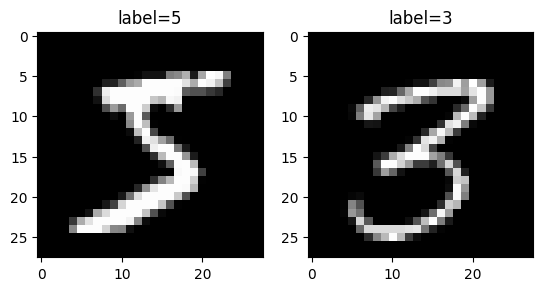

In [7]:
# print information about the dataset:
print('information about downloaded MNIST')
print(mnist_train_dataset)
print(f'shape of full images array: {mnist_train_dataset.data.shape}')
print(f'shape of full labels array: {mnist_train_dataset.targets.shape}')
n_elements = mnist_train_dataset.data.shape[0]
img_shape, label_shape = mnist_train_dataset.data.shape[1:], mnist_train_dataset.targets.shape[1:]
print(f'n_dataset_elements: {n_elements}')
print(f'shape of individual images: {img_shape}')
print(f'shape of individual labels: {label_shape}')

# we can access an individual element by indexing the dataset
first_img = mnist_train_dataset.data[0]
first_img_label = mnist_train_dataset.targets[0]
rnd_index = np.random.randint(n_elements) # numpy function for random integers
rnd_img = mnist_train_dataset.data[rnd_index]
rnd_img_label = mnist_train_dataset.targets[rnd_index]

# plot images + labels using the matplotlib package
fig, ax = plt.subplots(1,2)
ax[0].imshow(first_img, cmap='gray')
ax[0].set_title(f'label={first_img_label}')
ax[1].imshow(rnd_img, cmap='gray')
ax[1].set_title(f'label={rnd_img_label}')

>**Exercise 2:** Make the same plot as just above, but show three specifc images (e.g. the 99th, 128th and 600th image).

Text(0.5, 1.0, 'Img 600, label=9')

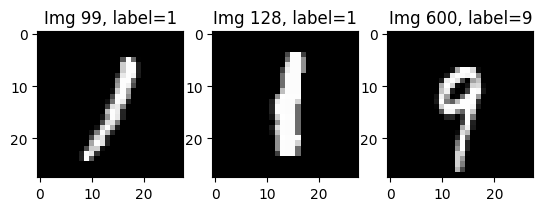

In [8]:
fig, ax = plt.subplots(1,3)
ax[0].imshow(mnist_train_dataset.data[99], cmap='gray')
ax[0].set_title(f'Img 99, label={mnist_train_dataset.targets[99]}')
ax[1].imshow(mnist_train_dataset.data[128], cmap='gray')
ax[1].set_title(f'Img 128, label={mnist_train_dataset.targets[128]}')
ax[2].imshow(mnist_train_dataset.data[600], cmap='gray')
ax[2].set_title(f'Img 600, label={mnist_train_dataset.targets[600]}')

**<font color='red'>Important note 1:</font>** Most stuff in pytorch is a **<font color='red'>tensor</font>**, i.e., a multidimensional array similar to a NumPy array, but with additional capabilities optimized for deep learning, such as the ability to be deployed on a GPU, and to be used with backpropagation.

That's great but it means that you can't run numpy operations on tensors. For example `np.mean(mnist_train_dataset.data)` will throw an error if `mnist_train_dataset.data` is a pytorch tensor.

Therefore, if you want to use numpy operations on tensors, you need to convert them to numpy arrays first. Below is an example.

In [9]:
# THE FOLLOWING WOULD THROW AN ERROR
# print(np.mean(mnist_train_dataset.data))

# # CORRECT WAY TO DO IT:
print(np.mean(mnist_train_dataset.data.numpy()))

33.318421449829934


**<font color='red'>Important note 2:</font>** It is fine to convert stuff to numpy that will not ultimately be fed into networks.

***However:*** Never convert something that will need to be trained with backprop to a numpy array! Otherwise backprop will not work.

###PyTorch Dataloaders

In pytorch, we can use DataLoaders for efficient dataset management (this becomes crucial with large datasets). Dataloaders can use multiple cores/CPUs in order to parallelize the loading of items (here, images+labels) from the disk. They return batches of data that we can easily feed into ANNs.

To get just one batch, we can use `next(iter(dataloader))`. To get all the batches one by one, we can use a for loop (e.g. `for batch_imgs, batch_labels in dataloader`).

Here are examples of how to use both approaches.

In [10]:
print('Printing using for loop')
counter = 0
for batch_imgs, batch_labels in mnist_train_loader:
    print(f'Batch number: {counter}')
    print(f'shape of batch_imgs: {batch_imgs.shape}')
    print(f'shape of batch_labels: {batch_labels.shape}')
    # get out of the for loop (because we don't want to print the whole dataset)
    if counter == 2:
        break
    counter += 1

print('\nPrinting using next(iter(dataloader))')
batch_imgs, batch_labels = next(iter(mnist_train_loader))
print(f'shape of batch_imgs: {batch_imgs.shape}')
print(f'shape of batch_labels: {batch_labels.shape}')

Printing using for loop
Batch number: 0
shape of batch_imgs: torch.Size([64, 1, 28, 28])
shape of batch_labels: torch.Size([64])
Batch number: 1
shape of batch_imgs: torch.Size([64, 1, 28, 28])
shape of batch_labels: torch.Size([64])
Batch number: 2
shape of batch_imgs: torch.Size([64, 1, 28, 28])
shape of batch_labels: torch.Size([64])

Printing using next(iter(dataloader))
shape of batch_imgs: torch.Size([64, 1, 28, 28])
shape of batch_labels: torch.Size([64])


>***Quick test:*** Interpet the values printed from img_batch.shape. What does each dimension represent?

>>*Solution:* Even though we only loaded one element from the dataloader, we got 'batch_size' image-label pairs, as expected (this is the 64 in dimension 0).

>>We can also see that each image has a shape [1, 28 ,28]. The first number corresponds to the rgb_channels. In this case, there is only one channel, indicating a grayscale image without color information. **Note that, as discussed several times, in pytorch, the channels are expected as the first dimension of images!**

>**Exercise 3:** Plot the image and label of the 5th image in batch number 8.

>>Hint: You can use the for loop technique to go through the batches and stop when you reach the 8th one.

Counter: 8


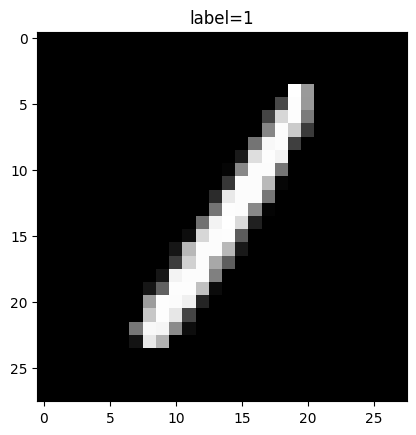

In [11]:
counter = 0
for batch_imgs, batch_labels in mnist_train_loader:
    # get out of the for loop when counter == 8
    if counter == 8:
        print(f'Counter: {counter}')
        img_to_plot = batch_imgs[4]
        label_to_plot = batch_labels[4]
        fig, ax = plt.subplots(1,1)
        ax.imshow(img_to_plot.permute(1,2,0), cmap='gray')
        ax.set_title(f'label={label_to_plot}')
        break
    counter += 1

#Exercise 4: Creating an augmented and normalized training set

Now, you should be able to make your own dataloader for MNIST. We want to add two features:

1. **Data augmentation** is a common practice to improve training datasets. Images are slightly modified (e.g. rotated, scaled, etc) in each training batch. This ensures that the network does not see exactly the same image repeatedly, and helps avoid overfitting. This can be done in pytorch using random transforms (i.e. transforms whose parameters change for each generated batch). For example, we could use `transforms.RandomRotation(angle=5)`. Apply this transform, and feel free to play around with the parameters or try other transforms.

2. **Normalization:** In general, ANNs work best when the input data is normalized. A common approach is to compute the mean and std of the entire dataset, and normalize using `norm_img = (img-dataset_mean)/dataset_std`. Compute  `dataset_mean` and `dataset_std` of the existing dataset, and apply this normalization using `transforms.Normalize`. *NOTE: If you compute `dataset_mean` and `dataset_std` on the raw dataset, you will need to divide by 255 because ToTensor() divides by 255 (ask me next time if you don't get this).*

3. **Training set:** Like most datasets in machine learning, MNIST is divided into a training and a testing set. We want to just get the training images here. We can easily do this by adding `train=True` as a new argument when getting the mnist dataset.

4. **Shuffling:** Finally, we want to shuffle the order of items in the dataset. This ensures that the model sees a diverse mix of examples in each batch during training. We can easily do this by adding `shuffle=True` as a new argument to the data_loader

**Feel free to check the pytorch documentation online, and/or to get inspired by code from earlier.**

---

*Bonus question 1: Should you normalize before or after the data augmentations? Why?*

*Bonus question 2: Would using vertical flipping (i.e., randomly flip the images upside-down) make sense for augmenting MNIST?*

---

In [12]:
# To start, we declare our transforms list, and add the .ToTensor() as before.
transform_list = []
transform_list.append(transforms.ToTensor())

# START OF EXERCISE CODE
# COMMENT OUT 'raise NotImplementedError()'
# raise NotImplementedError()

# first, we do data augmentation.
# Please append transforms.RandomRotation(degrees=5) to the transform_list.
transform_list.append(transforms.RandomRotation(degrees=5))

# second, we want to normalize each image by the mean and std of the dataset.
# We will use transforms.Normalize(mean=(dataset_mean,), std=(dataset_std,)).
# Please compute the mean (using np.mean) and std (using np.std) of the dataset.
# and print them, to see what you are dealing with.
# Recall that the raw data is in [0,255], and .ToTensor() will divide by 255
# to bring the data in the [0,1] range expected by pytorch. Therefore, you may
# need to divide by 255, depending on how you compute the mean and std.
dataset_mean = np.mean(mnist_train_dataset.data.numpy()/255)
dataset_std = np.std(mnist_train_dataset.data.numpy()/255)
print(dataset_mean, dataset_std)

# Once you have the mean & std append the corresponding transforms.Normalize.
transform_list.append(transforms.Normalize(mean=(dataset_mean,), std=(dataset_std,)))
print(transform_list)

# combine all transforms using transforms.Compose (see the previous example
# code if needed)
transform_train = transforms.Compose(transform_list)

# Get the training set of MNIST using torchvision.datasets.MNIST.
# make sure you only use the training images (i.e., add the train=True param).
mnist_train = torchvision.datasets.MNIST(root='../data', train=True,
                                         transform=transform_train)

# Finally, make a DataLoader to read from the mnist_train dataset you just made,
# and pass the transforms object you just made.
mnist_dataloader_train = DataLoader(dataset=mnist_train, batch_size=batch_size,
                              num_workers=2, shuffle=True)
# END OF EXERCISE CODE

0.1306604762738429 0.3081078038564622
[ToTensor(), RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0), Normalize(mean=(np.float64(0.1306604762738429),), std=(np.float64(0.3081078038564622),))]


Now plot some samples using our previously created function to plot dataset samples.

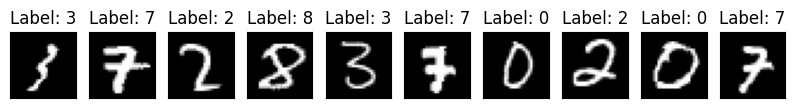

In [13]:
plot_dataset_samples(mnist_dataloader_train, 10)

##Exercise 5: Create a normalized but non-augmented and non-shuffled test set

If we normalize the training set, we also need to normalize the test set in the same way, otherwise the network will be confused and mess up the test set performance!

However, we don't want to augment (because we want to test on "real, normal" images) or shuffle (because the order only matters while training) the test set.

Fill in the code below.

In [14]:
transform_list = []
transform_list.append(transforms.ToTensor())
transform_list.append(transforms.Normalize(mean=(dataset_mean,), std=(dataset_std,)))
transform_test = transforms.Compose(transform_list)

mnist_test = torchvision.datasets.MNIST(root='../data', train=False,
                                        transform=transform_test)

mnist_dataloader_test = DataLoader(dataset=mnist_test, batch_size=batch_size,
                             num_workers=2, shuffle=False)

Plot a few samples from this test dataset.

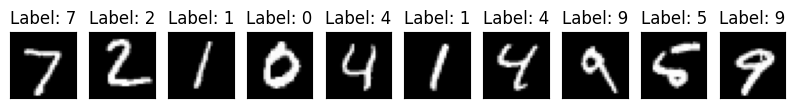

In [15]:
plot_dataset_samples(mnist_dataloader_test, 10)

##Exercise 6: Make a new network and train/test it on the datasets you just created

This time, I'm not helping you out by providing the code structure. Try to look back into the code from previous sessions to see how to create and train a network!

>Note: don't re-write the the network, the train_and_test() function, etc, from scratch! Use the ones imported above (copy-pasted from the previous session)

Epoch 1/2


Epoch 1:   0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.5348906517028809

  0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 1.5351, Accuracy: 93.22%
Epoch 2/2


Epoch 2:   0%|          | 0/938 [00:00<?, ?it/s]

Batch Loss: 1.4834243059158325

  0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 1.5192, Accuracy: 94.56%


Text(0, 0.5, 'loss')

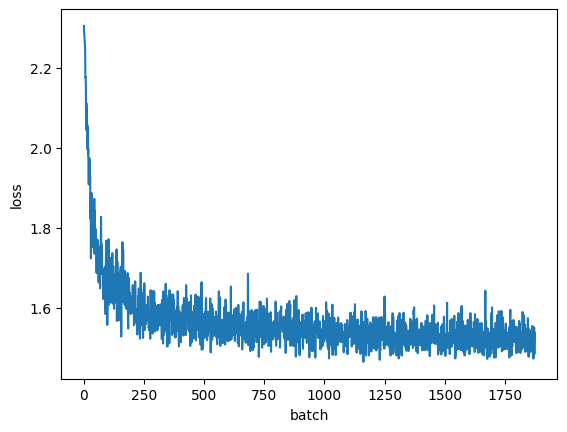

In [16]:
# Create an instance of the model
mnist_model = SimpleMLP(n_input_pixels=28*28, n_hidden=64)

# Move the model to the desired device
mnist_model = mnist_model.to(device)

# criterion & optimizer
mnist_criterion = nn.CrossEntropyLoss()  # Standardly used for classification
mnist_optimizer = torch.optim.Adam(mnist_model.parameters(), lr=0.001)

# train and test
history = train_and_test(mnist_model, mnist_dataloader_train, mnist_dataloader_test, 2,
                         mnist_criterion, mnist_optimizer, device)

# plot training performance over time
plt.plot(history)
plt.xlabel('batch')
plt.ylabel('loss')

Does it look like your network learned well?

Now plot some predictions from your network **on the test set** using our familiar plotting function. And make sure that the netow

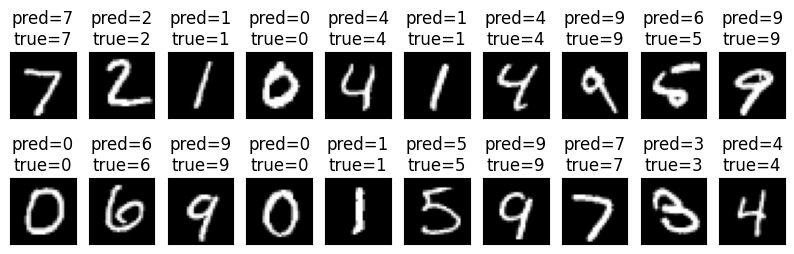

In [17]:
plot_batch_predictions(mnist_model, mnist_dataloader_test, 20)